In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.6 MB/s eta 0:00:00


In [27]:
!pip install isbnlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.1 MB/s eta 0:00:00


In [1]:
import os
print(os.getcwd())

/content


In [24]:
import os
os.chdir("/content/drive/MyDrive/BookVerse")

In [25]:
import sys
import os
sys.path.append(os.getcwd())

In [28]:
import pandas as pd
import numpy as np
import pickle
from utils.recommender import collaborative_recommendations, hybrid_recommendations


In [12]:
import os
books = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books_final.csv")
popular_books = pd.read_csv( "/content/drive/MyDrive/BookVerse/models/popularity_model.csv")
books_cf = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books_cf.csv")
ratings = pd.read_csv("/content/drive/MyDrive/BookVerse/models/ratings_cf.csv")

with open("/content/drive/MyDrive/BookVerse/models/tfidf_vectorizer.pkl","rb") as f:
    tfidf = pickle.load(f)

with open("/content/drive/MyDrive/BookVerse/models/tfidf_matrix.pkl","rb") as f:
    tfidf_matrix = pickle.load(f)

with open("/content/drive/MyDrive/BookVerse/models/book_indices.pkl","rb") as f:
    indices = pickle.load(f)

with open("/content/drive/MyDrive/BookVerse/models/svd_model.pkl","rb") as f:
    svd = pickle.load(f)

with open("/content/drive/MyDrive/BookVerse/models/genre_popularity.pkl","rb") as f:
    genre_popularity = pickle.load(f)

In [11]:
import pandas as pd
import numpy as np

ratings = pd.read_csv("/content/drive/MyDrive/BookVerse/models/ratings_cf.csv")
books_cf = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books_cf.csv")
books = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books_final.csv")
books_original = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books.csv")

In [ ]:
books.shape

(42309, 15)

In [ ]:
popular_books.head()

,bookId,title,author,series,genres,description,publisher,language,rating,numRatings,likedPercent,coverImg,combined_features,score
0,17332218-words-of-radiance,words of radiance,brandon sanderson goodreads author,the stormlight archive,"['fantasy', 'fiction', 'epic fantasy', 'high f...",words of radiance book two of the stormlight a...,tor books,English,4.75,207369,99.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'fiction', 'epic fantasy', 'high f...",4.719325
1,24812.The_Complete_Calvin_and_Hobbes,the complete calvin and hobbes,bill watterson,calvin and hobbes,"['comics', 'humor', 'graphic novels', 'fiction...",box set book one book two book three calvin an...,andrews mcmeel publishing,English,4.82,34893,99.0,https://i.gr-assets.com/images/S/compressed.ph...,"['comics', 'humor', 'graphic novels', 'fiction...",4.654523
2,136251.Harry_Potter_and_the_Deathly_Hallows,harry potter and the deathly hallows,j k rowling,harry potter,"['fantasy', 'young adult', 'fiction', 'magic',...",harry potter is leaving privet drive for the l...,arthur a levine books scholastic inc,English,4.62,2811637,98.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.618064
3,50196744-know-my-name,know my name,chanel miller,NaN,"['nonfiction', 'memoir', 'feminism', 'audioboo...",she was known to the world as emily doe when s...,viking,English,4.71,55887,99.0,https://i.gr-assets.com/images/S/compressed.ph...,"['nonfiction', 'memoir', 'feminism', 'audioboo...",4.613357
4,7235533-the-way-of-kings,the way of kings,brandon sanderson goodreads author,the stormlight archive,"['fantasy', 'fiction', 'epic fantasy', 'high f...",from new york times bestselling author brandon...,tor books,English,4.63,302877,98.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'fiction', 'epic fantasy', 'high f...",4.612202


In [ ]:
ratings.shape

(5976479, 3)

Dataset Summary

In [ ]:
print("BOOK RECOMMENDATION SYSTEM - MODEL EVALUATION")
print(f"Books Dataset          : {len(books):,}")
print(f"Popularity Books       : {len(popular_books):,}")
print(f"Collaborative Books    : {len(books_cf):,}")
print(f"Ratings                : {len(ratings):,}")

print("\nUnique Users :", ratings["user_id"].nunique())
print("Unique Books :", ratings["book_id"].nunique())

BOOK RECOMMENDATION SYSTEM - MODEL EVALUATION
Books Dataset          : 42,309
Popularity Books       : 12,250
Collaborative Books    : 10,000
Ratings                : 5,976,479

Unique Users : 53424
Unique Books : 10000


Popularity recommendation Evaluation

In [ ]:
print("TOP 7 POPULAR BOOKS")

display(
    popular_books[
        [
            "title",
            "author",
            "rating",
            "score"
        ]
    ].head(7)
)

TOP 7 POPULAR BOOKS


,title,author,rating,score
0,words of radiance,brandon sanderson goodreads author,4.75,4.719325
1,the complete calvin and hobbes,bill watterson,4.82,4.654523
2,harry potter and the deathly hallows,j k rowling,4.62,4.618064
3,know my name,chanel miller,4.71,4.613357
4,the way of kings,brandon sanderson goodreads author,4.63,4.612202
5,a court of mist and fury,sarah j maas goodreads author,4.62,4.604017
6,the essential calvin and hobbes a calvin and h...,bill watterson,4.64,4.593323


In [ ]:
print("Average Rating :",
      round(popular_books["rating"].mean(),2))

print("Highest Rating :",
      round(popular_books["rating"].max(),2))

print("Lowest Rating :",
      round(popular_books["rating"].min(),2))

Average Rating : 4.02
Highest Rating : 4.82
Lowest Rating : 2.51


In [ ]:
print("Available Genres:")
for genre in genre_popularity.keys():
    print(genre)

Available Genres:
Fantasy
Romance
Young Adult
Mystery
Classics
Science Fiction
Historical Fiction
Thriller
Adventure
Horror


In [ ]:
display(
    genre_popularity["Fantasy"][
        [
            "title",
            "author",
            "rating",
            "score"
        ]
    ].head(10)
)

,title,author,rating,score
0,words of radiance,brandon sanderson goodreads author,4.75,4.719325
2,harry potter and the deathly hallows,j k rowling,4.62,4.618064
4,the way of kings,brandon sanderson goodreads author,4.63,4.612202
5,a court of mist and fury,sarah j maas goodreads author,4.62,4.604017
7,harry potter and the order of the phoenix harr...,j k rowling,4.62,4.568826
8,harry potter and the chamber of secrets sheet ...,john williams,4.64,4.568339
9,harry potter and the prisoner of azkaban,j k rowling mary grandpr illustrator,4.57,4.568221
10,harry potter and the half blood prince,j k rowling,4.57,4.567953
15,harry potter and the goblet of fire,j k rowling mary grandpr illustrator,4.56,4.558111
16,clockwork princess,cassandra clare goodreads author,4.57,4.555534


 Content based Recommendation Evaluation

In [10]:
test_books = [
    "the hunger games — suzanne collins",
    "harry potter and the deathly hallows — j k rowling",
    "red rising — pierce brown goodreads author",
    "six of crows — leigh bardugo goodreads author",
    "a good girl s guide to murder — holly jackson goodreads author"
]

In [8]:
#content based recs function
from sklearn.metrics.pairwise import cosine_similarity
def get_content_recommendations(book_title, top_n=10):
    idx = indices[book_title]
    similarity_scores = cosine_similarity(tfidf_matrix[idx],tfidf_matrix).flatten()
    similar_indices = similarity_scores.argsort()[::-1]
    similar_indices = similar_indices[
        similar_indices != idx
    ]
    similar_indices = similar_indices[:100]
    recommendations = books.iloc[similar_indices][
      [
        "bookId",
        "title",
        "author",
        "genres",
        "rating",
        "coverImg",
        "display_title"
      ]].copy()

    recommendations["recommendation_score"] = (similarity_scores[similar_indices])
    recommendations["recommendation_type"] = "Content"
    recommendations = recommendations[
       books.loc[recommendations.index, "is_main_book"].values
    ]
    recommendations = recommendations.drop_duplicates(subset="title")
    final_recommendations = []
    author_count = {}

    for _, row in recommendations.iterrows():
        author = row["author"]
        if author not in author_count:
            author_count[author] = 0
        if author_count[author] < 2:
            final_recommendations.append(row)
            author_count[author] += 1
        if len(final_recommendations) == top_n:
            break

    if len(final_recommendations) < top_n:
        existing_titles = {
            row["title"]
            for row in final_recommendations
        }

        for _, row in recommendations.iterrows():
            if row["title"] not in existing_titles:
                final_recommendations.append(row)
                existing_titles.add(row["title"])
            if len(final_recommendations) == top_n:
                break

    return pd.DataFrame(final_recommendations)

In [13]:
get_content_recommendations("the hunger games — suzanne collins", top_n=5)

,bookId,title,author,genres,rating,coverImg,display_title,recommendation_score,recommendation_type
219,6148028-catching-fire,catching fire,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.29,https://i.gr-assets.com/images/S/compressed.ph...,catching fire — suzanne collins,0.370203,Content
323,7260188-mockingjay,mockingjay,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.04,https://i.gr-assets.com/images/S/compressed.ph...,mockingjay — suzanne collins,0.343412,Content
21,13335037-divergent,divergent,veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.19,https://i.gr-assets.com/images/S/compressed.ph...,divergent — veronica roth goodreads author,0.162456,Content
24628,13451182-arena-one,arena one slaverunners,morgan rice goodreads author,"['dystopia', 'young adult', 'post apocalyptic'...",3.37,https://i.gr-assets.com/images/S/compressed.ph...,arena one slaverunners — morgan rice goodreads...,0.154904,Content
151,11735983-insurgent,insurgent,veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.02,https://i.gr-assets.com/images/S/compressed.ph...,insurgent — veronica roth goodreads author,0.149286,Content


In [14]:
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ratings = pd.read_csv("/content/drive/MyDrive/BookVerse/models/ratings_cf.csv")
books_cf = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books_cf.csv")
books = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books_final.csv")
books_original = pd.read_csv("/content/drive/MyDrive/BookVerse/models/books.csv")

In [ ]:
result = get_content_recommendations(
    "the hunger games — suzanne collins",
    top_n=5
)
result

,bookId,title,author,genres,rating,coverImg,display_title,recommendation_score,recommendation_type
219,6148028-catching-fire,catching fire,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.29,https://i.gr-assets.com/images/S/compressed.ph...,catching fire — suzanne collins,0.370203,Content
323,7260188-mockingjay,mockingjay,suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.04,https://i.gr-assets.com/images/S/compressed.ph...,mockingjay — suzanne collins,0.343412,Content
21,13335037-divergent,divergent,veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.19,https://i.gr-assets.com/images/S/compressed.ph...,divergent — veronica roth goodreads author,0.162456,Content
24628,13451182-arena-one,arena one slaverunners,morgan rice goodreads author,"['dystopia', 'young adult', 'post apocalyptic'...",3.37,https://i.gr-assets.com/images/S/compressed.ph...,arena one slaverunners — morgan rice goodreads...,0.154904,Content
151,11735983-insurgent,insurgent,veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.02,https://i.gr-assets.com/images/S/compressed.ph...,insurgent — veronica roth goodreads author,0.149286,Content


In [15]:
goodreads_to_cf = dict(
    zip(
        books_cf["goodreads_book_id"].astype(str),
        books_cf["book_id"]
    )
)

def bookmate_to_cf(bookmate_id):
    if pd.isna(bookmate_id):
        return None
    try:
        goodreads_id = str(bookmate_id).split("-")[0]
    except Exception:
        return None

    return goodreads_to_cf.get(goodreads_id)

In [ ]:
book = books.iloc[0]
print(book["bookId"])
print(bookmate_to_cf(book["bookId"]))

2767052-the-hunger-games
1


In [16]:
def get_ground_truth(bookmate_id, min_rating=4):
    cf_book = bookmate_to_cf(bookmate_id)
    if cf_book is None:
        return set()

    users = ratings[
        (ratings["book_id"] == cf_book) &
        (ratings["rating"] >= min_rating)
    ]["user_id"].unique()

    users = users[:300]

    ground_truth = (
        ratings[
            (ratings["user_id"].isin(users)) &
            (ratings["rating"] >= min_rating)
        ]
        .groupby("book_id")
        .agg(
            frequency=("user_id", "count"),
            avg_rating=("rating", "mean")
        )
    )

    ground_truth["score"] = (
        ground_truth["frequency"] * 0.7 +
        ground_truth["avg_rating"] * 0.3
    )

    ground_truth = (
        ground_truth
        .sort_values("score", ascending=False)
        .head(30)
        .index
    )

    return set(ground_truth)

In [17]:
book = books.iloc[0]
gt = get_ground_truth(book["bookId"])
print("Ground Truth Size:", len(gt))
print(list(gt)[:10])

Ground Truth Size: 30
[1, 2, 3, 4, 10, 12, 144, 17, 18, 20]


In [18]:
def get_predicted_cf(bookmate_id, top_n=10):
    row = books[books["bookId"] == bookmate_id]
    if row.empty:
        return set()
    display_title = row.iloc[0]["display_title"]
    recs = get_content_recommendations(
        display_title,
        top_n=top_n
    )

    cf_predictions = set()
    for rec_bookid in recs["bookId"]:
        cf_id = bookmate_to_cf(rec_bookid)
        if cf_id is not None:
            cf_predictions.add(cf_id)

    return cf_predictions

In [19]:
pred = get_predicted_cf(book["bookId"], top_n=20)

print(pred)
print(len(pred))

{2916, 69, 327, 12, 17, 20, 3318}
7


In [42]:
import random
def evaluate_book(bookmate_id, top_n=20, candidate_size=100):
    ground_truth = get_ground_truth(bookmate_id)
    predictions = get_predicted_cf(bookmate_id, top_n)
    non_relevant = list(set(ratings["book_id"].unique()) - ground_truth)

    random.seed(42)
    needed = max(0, candidate_size - len(ground_truth))
    candidate_pool = (
        set(ground_truth) |
        set(random.sample(non_relevant, min(needed, len(non_relevant))))
    )

    predictions = predictions & candidate_pool
    tp = len(predictions & ground_truth)
    fp = len(predictions - ground_truth)
    fn = len(ground_truth - predictions)
    tn = len(candidate_pool) - tp - fp - fn

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0

    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision@20": precision,
        "Recall@20": recall
    }

In [21]:
result = evaluate_book(book["bookId"], top_n=20)
result

{'TP': 3, 'FP': 0, 'FN': 27, 'TN': 70, 'Precision@20': 1.0, 'Recall@20': 0.1}

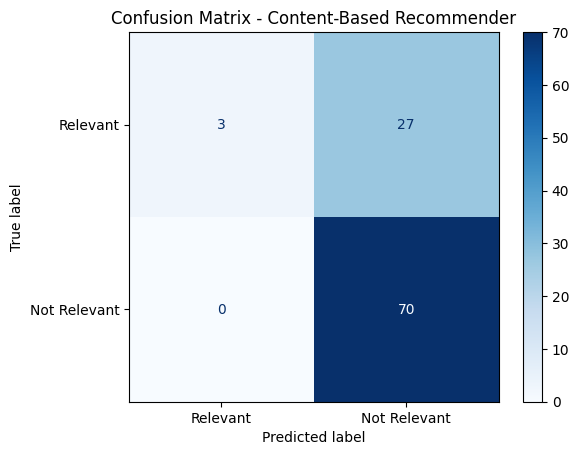

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [result["TP"], result["FN"]],
    [result["FP"], result["TN"]]])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Relevant", "Not Relevant"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Content-Based Recommender")
plt.show()

In [35]:
valid_books = books[ books["bookId"].apply(lambda x: bookmate_to_cf(x) is not None)]
print("Total books:", len(books))
print("Valid books:", len(valid_books))

Total books: 42309
Valid books: 2763


In [44]:
sample_books = valid_books.sample(
    min(100, len(valid_books)),
    random_state=42
)

results = []

for _, row in sample_books.iterrows():
    try:
        results.append(
            evaluate_book(
                row["bookId"],
                top_n=20,
                candidate_size=50
            )
        )
    except Exception:
        continue

evaluation = pd.DataFrame(results)

display(evaluation.mean(numeric_only=True).round(3))

total_tp = evaluation["TP"].sum()
total_fp = evaluation["FP"].sum()
total_fn = evaluation["FN"].sum()
total_tn = evaluation["TN"].sum()


,0
TP,0.790
FP,0.010
FN,29.210
TN,19.990
Precision@20,0.547
Recall@20,0.026


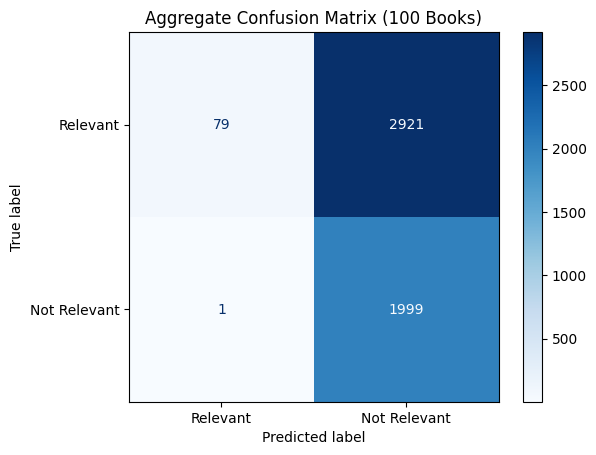

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [total_tp, total_fn],
    [total_fp, total_tn]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Relevant", "Not Relevant"]
)

disp.plot(cmap="Blues")
plt.title("Aggregate Confusion Matrix (100 Books)")
plt.show()

In [36]:
for book in test_books:
    print(book.upper())
    display(
        get_content_recommendations(
            book,
            top_n=5
        )[
            [
                "display_title",
                "genres",
                "rating",
                "recommendation_score"
            ]
        ]

    )

    print("\n")

THE HUNGER GAMES — SUZANNE COLLINS


,display_title,genres,rating,recommendation_score
219,catching fire — suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.29,0.370203
323,mockingjay — suzanne collins,"['young adult', 'dystopia', 'fiction', 'fantas...",4.04,0.343412
21,divergent — veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.19,0.162456
24628,arena one slaverunners — morgan rice goodreads...,"['dystopia', 'young adult', 'post apocalyptic'...",3.37,0.154904
151,insurgent — veronica roth goodreads author,"['young adult', 'dystopia', 'fiction', 'fantas...",4.02,0.149286




HARRY POTTER AND THE DEATHLY HALLOWS — J K ROWLING


,display_title,genres,rating,recommendation_score
3394,harry potter and the order of the phoenix harr...,"['fantasy', 'fiction', 'young adult', 'magic',...",4.62,0.413832
103,harry potter and the goblet of fire — j k rowl...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.56,0.384699
105,harry potter and the half blood prince — j k r...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.57,0.344843
1,harry potter and the order of the phoenix — j ...,"['fantasy', 'young adult', 'fiction', 'magic',...",4.50,0.344183
32860,the end of harry potter — david langford,"['nonfiction', 'magic', 'media tie in', 'love'...",4.41,0.260377




RED RISING — PIERCE BROWN GOODREADS AUTHOR


,display_title,genres,rating,recommendation_score
1979,golden son — pierce brown goodreads author,"['science fiction', 'fantasy', 'dystopia', 'fi...",4.44,0.266147
3046,morning star — pierce brown goodreads author,"['science fiction', 'fantasy', 'fiction', 'dys...",4.49,0.165277
24032,the empress — s j kincaid goodreads author,"['science fiction', 'young adult', 'fantasy', ...",3.84,0.125638
516,red queen — victoria aveyard goodreads author,"['fantasy', 'young adult', 'dystopia', 'romanc...",4.04,0.123928
1274,noughts crosses — malorie blackman goodreads a...,"['young adult', 'romance', 'fiction', 'dystopi...",4.23,0.122765




SIX OF CROWS — LEIGH BARDUGO GOODREADS AUTHOR


,display_title,genres,rating,recommendation_score
680,crooked kingdom — leigh bardugo goodreads author,"['fantasy', 'young adult', 'fiction', 'lgbt', ...",4.58,0.270509
28181,untitled — leigh bardugo goodreads author,"['fantasy', 'young adult', 'young adult fantas...",4.79,0.266710
3174,godsgrave — jay kristoff goodreads author,"['fantasy', 'adult', 'young adult', 'new adult...",4.53,0.161975
39216,frostfire — zo marriott goodreads author,"['fantasy', 'young adult', 'romance', 'young a...",4.05,0.132845
23097,the thief of kalimar — graham diamond goodread...,['fantasy'],3.43,0.132175




A GOOD GIRL S GUIDE TO MURDER — HOLLY JACKSON GOODREADS AUTHOR


,display_title,genres,rating,recommendation_score
20151,good girl bad blood — holly jackson goodreads ...,"['mystery', 'young adult', 'thriller', 'myster...",4.52,0.317414
29966,the cheerleaders — kara thomas,"['mystery', 'young adult', 'thriller', 'contem...",3.81,0.190102
10107,two can keep a secret — karen m mcmanus goodre...,"['mystery', 'young adult', 'thriller', 'contem...",3.98,0.175499
32525,the girl i used to be — april henry goodreads ...,"['mystery', 'young adult', 'thriller', 'fictio...",3.93,0.164786
21502,to catch a killer — sheryl scarborough goodrea...,"['mystery', 'young adult', 'thriller', 'contem...",3.80,0.156284


In [ ]:
test_books = [
    "the hunger games — suzanne collins",
    "harry potter and the deathly hallows — j k rowling",
    "red rising — pierce brown goodreads author",
    "six of crows — leigh bardugo goodreads author",
    "a good girl s guide to murder — holly jackson goodreads author"
]
scores = []

for book in test_books:
    recs = get_content_recommendations(
        book,
        top_n=10
    )
    scores.extend(
        recs["recommendation_score"]
    )

print("CONTENT-BASED SIMILARITY")
print("Average Similarity Score :",round(np.mean(scores),3))
print("Highest Similarity Score :",round(np.max(scores),3))
print("Lowest Similarity Score :",round(np.min(scores),3))

CONTENT-BASED SIMILARITY
Average Similarity Score : 0.185
Highest Similarity Score : 0.414
Lowest Similarity Score : 0.108


In [ ]:
ratings_list = []
for book in test_books:
    recs = get_content_recommendations(
        book,
        top_n=10
    )
    ratings_list.extend(
        recs["rating"]
    )
print("RECOMMENDED BOOK RATINGS")
print("Average Rating :",round(np.mean(ratings_list),2))
print("Highest Rating :",round(np.max(ratings_list),2))
print("Lowest Rating :",round(np.min(ratings_list),2))

RECOMMENDED BOOK RATINGS
Average Rating : 4.1
Highest Rating : 4.79
Lowest Rating : 3.23


In [ ]:
all_genres = set()
for book in test_books:
    recs = get_content_recommendations(
        book,
        top_n=10
    )
    for genre_list in recs["genres"]:
        try:
            genres = eval(genre_list)
        except:
            genres = []
        all_genres.update(genres)

print("GENRE COVERAGE")
print("Unique Genres Covered :", len(all_genres))
print("Genres Found:\n")
print(sorted(all_genres))

GENRE COVERAGE
Unique Genres Covered : 72
Genres Found:

['action', 'adult', 'adventure', 'aliens', 'apocalyptic', 'audiobook', 'books about books', 'childrens', 'classics', 'contemporary', 'crime', 'detective', 'dragons', 'drama', 'dystopia', 'epic', 'epic fantasy', 'erotica', 'fan fiction', 'fantasy', 'fiction', 'hard science fiction', 'high fantasy', 'historical', 'historical fantasy', 'historical fiction', 'hugo awards', 'humor', 'lgbt', 'love', 'm m romance', 'magic', 'magical realism', 'media tie in', 'middle grade', 'murder mystery', 'mystery', 'mystery thriller', 'mythology', 'new adult', 'nonfiction', 'novels', 'paranormal', 'philosophy', 'plays', 'police', 'politics', 'post apocalyptic', 'queer', 'race', 'realistic fiction', 'romance', 'romantic suspense', 'science fiction', 'science fiction fantasy', 'short stories', 'space', 'space opera', 'speculative fiction', 'supernatural', 'survival', 'suspense', 'teen', 'thriller', 'time travel', 'unfinished', 'urban fantasy', 'virtua

In [ ]:
authors = []
for book in test_books:
    recs = get_content_recommendations(
        book,
        top_n=10
    )
    authors.extend(
        recs["author"]
    )

unique_authors = len(set(authors))
print("AUTHOR DIVERSITY")
print("Total Recommendations :", len(authors))
print("Unique Authors :", unique_authors)
print("Author Diversity Score :",round(unique_authors / len(authors),2))

AUTHOR DIVERSITY
Total Recommendations : 50
Unique Authors : 41
Author Diversity Score : 0.82


In [ ]:
import time
times = []
for book in test_books:
    start = time.time()
    get_content_recommendations(
        book,
        top_n=10
    )
    end = time.time()
    times.append(end-start)

print("RECOMMENDATION SPEED")
print("Average Time :",round(np.mean(times),4),"seconds")
print("Fastest :",round(np.min(times),4),"seconds")
print("Slowest :",round(np.max(times),4),"seconds")

RECOMMENDATION SPEED
Average Time : 0.1401 seconds
Fastest : 0.136 seconds
Slowest : 0.1467 seconds


collaborative evalution

In [29]:
test_book = books.iloc[0]["bookId"]
cf = collaborative_recommendations(
    test_book,
    top_n=5
)
cf.columns.tolist()

Received: 2767052-the-hunger-games
                     bookId             title               series  \
0  2767052-the-hunger-games  The Hunger Games  The Hunger Games #1   

            author  rating                                        description  \
0  Suzanne Collins    4.33  WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...   

  language           isbn                                             genres  \
0  English  9780439023481  ['Young Adult', 'Fiction', 'Dystopia', 'Fantas...   

                                          characters  ... firstPublishDate  \
0  ['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...  ...              NaN   

                                              awards numRatings  \
0  ['Locus Award Nominee for Best Young Adult Boo...    6376780   

                                      ratingsByStars likedPercent  \
0  ['3444695', '1921313', '745221', '171994', '93...         96.0   

                                             setting  \
0  ['District

['bookId',
 'title',
 'author',
 'series',
 'genres',
 'description',
 'publisher',
 'language',
 'rating',
 'numRatings',
 'likedPercent',
 'coverImg',
 'combined_features',
 'is_main_book',
 'display_title']

In [ ]:
test_book = books.iloc[0]["bookId"]

cf = collaborative_recommendations(
    test_book,
    top_n=5
)

print(cf["bookId"].tolist())

['6148028-catching-fire', '7260188-mockingjay', '136251.Harry_Potter_and_the_Deathly_Hallows', '5.Harry_Potter_and_the_Prisoner_of_Azkaban', '2.Harry_Potter_and_the_Order_of_the_Phoenix']


In [30]:
def get_cf_predicted(bookmate_id, top_n=20):

    recs = collaborative_recommendations(
        bookmate_id,
        top_n=top_n
    )

    predictions = set()

    for rec_book in recs["bookId"]:

        cf_id = bookmate_to_cf(rec_book)

        if cf_id is not None:
            predictions.add(cf_id)

    return predictions

In [ ]:
pred = get_cf_predicted(test_book, top_n=20)

print(pred)
print(len(pred))

In [32]:
import time
import numpy as np
test_book = books.iloc[0]["bookId"]
start = time.time()

cf = collaborative_recommendations(
    test_book,
    top_n=10
)
end = time.time()
print("APPLICATION COLLABORATIVE RECOMMENDATION")
display(
    cf[
        [
            "display_title",
            "author",
            "genres",
            "rating"
        ]
    ]
)

print()
print("Total Recommendations :", len(cf))
print("Average Rating :", round(cf["rating"].mean(),2))
print("Highest Rating :", round(cf["rating"].max(),2))
print("Lowest Rating :", round(cf["rating"].min(),2))
print("Runtime :", round(end-start,4),"seconds")

Received: 2767052-the-hunger-games
                     bookId             title               series  \
0  2767052-the-hunger-games  The Hunger Games  The Hunger Games #1   

            author  rating                                        description  \
0  Suzanne Collins    4.33  WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...   

  language           isbn                                             genres  \
0  English  9780439023481  ['Young Adult', 'Fiction', 'Dystopia', 'Fantas...   

                                          characters  ... firstPublishDate  \
0  ['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...  ...              NaN   

                                              awards numRatings  \
0  ['Locus Award Nominee for Best Young Adult Boo...    6376780   

                                      ratingsByStars likedPercent  \
0  ['3444695', '1921313', '745221', '171994', '93...         96.0   

                                             setting  \
0  ['District

,display_title,author,genres,rating
0,catching fire — suzanne collins,Suzanne Collins,Young Adult • Dystopia • Fiction • Fantasy • S...,4.29
1,mockingjay — suzanne collins,Suzanne Collins,Young Adult • Dystopia • Fiction • Fantasy • S...,4.04
2,harry potter and the deathly hallows — j k row...,J K,Fantasy • Young Adult • Fiction • Magic • Chil...,4.62
3,harry potter and the prisoner of azkaban — j k...,J K,Fantasy • Young Adult • Fiction • Magic • Chil...,4.57
4,the hobbit or there and back again — j r r tol...,J R,Fantasy • Classics • Fiction • Adventure • You...,4.27
5,divergent — veronica roth goodreads author,Veronica Roth,Young Adult • Dystopia • Fiction • Fantasy • S...,4.19
6,a game of thrones — george r r martin,George R,Fantasy • Fiction • Epic Fantasy • Adult • Sci...,4.45
7,the book thief — markus zusak goodreads author,Markus Zusak,Historical Fiction • Fiction • Young Adult • H...,4.37
8,twilight — stephenie meyer,Stephenie Meyer,Young Adult • Fantasy • Romance • Vampires • F...,3.60
9,the giver — lois lowry goodreads author,Lois Lowry,Young Adult • Fiction • Classics • Dystopia • ...,4.13



Total Recommendations : 10
Average Rating : 4.25
Highest Rating : 4.62
Lowest Rating : 3.6
Runtime : 0.8049 seconds


In [33]:
import random

def evaluate_cf(bookmate_id, top_n=20, candidate_size=100):

    ground_truth = get_ground_truth(bookmate_id)
    predictions = get_cf_predicted(bookmate_id, top_n)

    # Candidate pool
    non_relevant = list(
        set(ratings["book_id"].unique()) - ground_truth
    )
    random.seed(42)
    needed = max(0, candidate_size - len(ground_truth))
    candidate_pool = (
        set(ground_truth) |
        set(random.sample(non_relevant, min(needed, len(non_relevant))))
    )
    predictions = predictions & candidate_pool

    tp = len(predictions & ground_truth)
    fp = len(predictions - ground_truth)
    fn = len(ground_truth - predictions)
    tn = len(candidate_pool) - tp - fp - fn
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    return {
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "Precision@20": precision,
        "Recall@20": recall
    }

In [ ]:
result = evaluate_cf(
    test_book,
    top_n=20,
    candidate_size=100
)
print(result)

{'TP': 3, 'FP': 0, 'FN': 27, 'TN': 70, 'Precision@20': 1.0, 'Recall@20': 0.1}


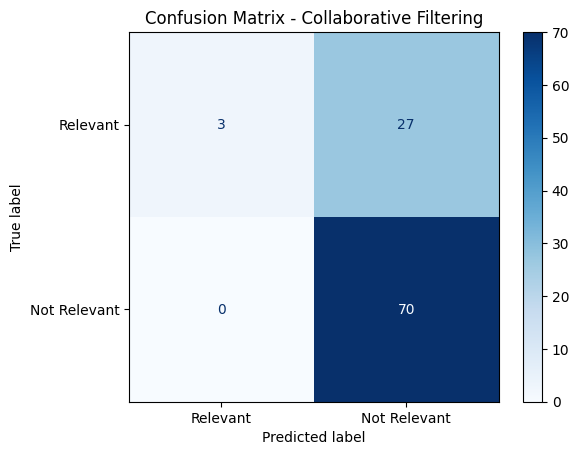

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
cm = np.array([
    [result["TP"], result["FN"]],
    [result["FP"], result["TN"]]
])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Relevant", "Not Relevant"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Collaborative Filtering")
plt.show()

In [46]:
sample_books = valid_books.sample(
    min(100, len(valid_books)),
    random_state=42
)

results = []

for _, row in sample_books.iterrows():
    try:
        results.append(
            evaluate_cf(
                row["bookId"],
                top_n=20,
                candidate_size=50
            )
        )
    except Exception:
        continue

evaluation_cf = pd.DataFrame(results)

display(evaluation_cf.mean(numeric_only=True).round(3))

total_tp = evaluation_cf["TP"].sum()
total_fp = evaluation_cf["FP"].sum()
total_fn = evaluation_cf["FN"].sum()
total_tn = evaluation_cf["TN"].sum()


Received: 18297707-tangled
                bookId    title      series                         author  \
1705  18297707-tangled  Tangled  Tangled #1  Emma Chase (Goodreads Author)   

      rating                                        description language  \
1705    4.08  Drew Evans is a winner. Handsome and arrogant,...  English   

            isbn                                             genres  \
1705  B00DJWV11I  ['Romance', 'Contemporary', 'Contemporary Roma...   

                              characters  ... firstPublishDate  \
1705  ['Drew Evans', 'Katherine Brooks']  ...         05/20/13   

                                                 awards numRatings  \
1705  ['All About Romance (AAR) Annual Reader Poll f...     106733   

                                   ratingsByStars likedPercent  \
1705  ['46418', '34143', '17715', '5330', '3127']         92.0   

                                          setting  \
1705  ['New York City, New York (United States)']   

      

,0
TP,7.878
FP,0.000
FN,22.122
TN,20.000
Precision@20,0.986
Recall@20,0.263


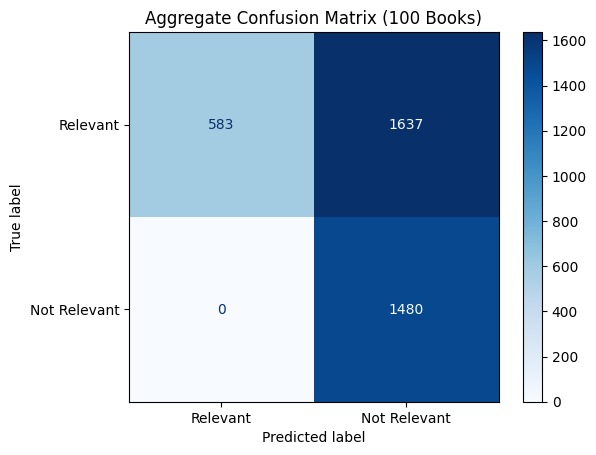

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [total_tp, total_fn],
    [total_fp, total_tn]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Relevant", "Not Relevant"]
)

disp.plot(cmap="Blues")
plt.title("Aggregate Confusion Matrix (100 Books)")
plt.show()

In [ ]:
unique_authors = cf["author"].nunique()
print("AUTHOR DIVERSITY")
print("Unique Authors :", unique_authors)
print("Diversity Score :", round(unique_authors/len(cf),2))

In [ ]:
all_genres = set()
for g in cf["genres"]:
    for genre in str(g).split("•"):
        genre = genre.strip()
        if genre:
            all_genres.add(genre)
print("GENRE COVERAGE")
print("Unique Genres :", len(all_genres))
print(sorted(all_genres))

GENRE COVERAGE
Unique Genres : 27
['Action', 'Adult', 'Adventure', 'Audiobook', 'Childrens', 'Classics', 'Dragons', 'Dystopia', 'Epic', 'Epic Fantasy', 'Fantasy', 'Fiction', 'High Fantasy', 'Magic', 'Middle Grade', 'Novels', 'Paranormal', 'Paranormal Romance', 'Post Apocalyptic', 'Romance', 'Science Fiction', 'Science Fiction Fantasy', 'Supernatural', 'Teen', 'Urban Fantasy', 'Vampires', 'Young Adult']


In [ ]:
selected = books[
    books["display_title"].isin([
        "Harry Potter and the Sorcerer's Stone",
        "The Hobbit",
        "The Hunger Games"
    ])
]["bookId"].tolist()

In [ ]:
import sqlite3
conn = sqlite3.connect(":memory:")

In [ ]:
books[books["display_title"].str.contains("fault", case=False, na=False)][
    ["bookId", "display_title"]
]

,bookId,display_title
10,11870085-the-fault-in-our-stars,the fault in our stars — john green goodreads ...
7022,2012337.Fault_Lines,fault lines — nancy huston
9014,15860080-looking-for-alaska-an-abundance-of-ka...,looking for alaska an abundance of katherines ...
9312,21112453-john-green-the-collection,john green the collection looking for alaska a...
18511,7184066-fault-lines,fault lines how hidden fractures still threate...
24889,19195803-death-by-default,death by default — trish reeb goodreads author
37967,6366365-double-fault,double fault — lionel shriver goodreads author...
40196,11595922-the-consumerist-manifesto-handbook,the consumerist manifesto handbook the guerill...
41153,4702458-it-s-not-my-fault-i-know-everything,it s not my fault i know everything — jim benton


In [ ]:
selected = ["2767052-the-hunger-games","13335037-divergent","6148028-catching-fire"]
hybrid = hybrid_recommendations(
    conn,
    user_id=1,
    selected_books=selected,
    top_n=10
)
display(hybrid)


,bookId,title,author,series,genres,description,publisher,language,rating,numRatings,likedPercent,coverImg,combined_features,is_main_book,display_title
0,13496.A_Game_of_Thrones,a game of thrones,George R R Martin,a song of ice and fire,Fantasy • Fiction • Epic Fantasy • Adult • Sci...,here is the first volume in george r r martin ...,bantam,English,4.45,2003043,96.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'fiction', 'epic fantasy', 'adult'...",True,a game of thrones — george r r martin
1,256683.City_of_Bones,city of bones,Cassandra Clare,the mortal instruments,Fantasy • Young Adult • Paranormal • Romance •...,when fifteen year old clary fray heads out to ...,margaret k mcelderry books,English,4.10,1617465,92.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fantasy', 'young adult', 'paranormal', 'roma...",True,city of bones — cassandra clare goodreads author
2,1934.Little_Women,little women,Louisa May Alcott,little women,Classics • Fiction • Historical Fiction • Youn...,generations of readers young and old male and ...,signet classics,English,4.09,1681583,93.0,https://i.gr-assets.com/images/S/compressed.ph...,"['classics', 'fiction', 'historical fiction', ...",True,little women — louisa may alcott
3,13335037-divergent,divergent,Veronica Roth,divergent,Young Adult • Dystopia • Fiction • Fantasy • S...,in beatrice prior s dystopian chicago world so...,katherine tegen books,English,4.19,2906258,94.0,https://i.gr-assets.com/images/S/compressed.ph...,"['young adult', 'dystopia', 'fiction', 'fantas...",True,divergent — veronica roth goodreads author
4,41865.Twilight,twilight,Stephenie Meyer,the twilight saga,Young Adult • Fantasy • Romance • Vampires • F...,about three things i was absolutely positive f...,little brown and company,English,3.60,4964519,78.0,https://i.gr-assets.com/images/S/compressed.ph...,"['young adult', 'fantasy', 'romance', 'vampire...",True,twilight — stephenie meyer
5,5060378-the-girl-who-played-with-fire,the girl who played with fire,Stieg Larsson Reg Keeland Translator,millennium,Fiction • Mystery • Thriller • Crime • Mystery...,part blistering espionage thriller part riveti...,alfred a knopf,English,4.24,809293,97.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fiction', 'mystery', 'thriller', 'crime', 'm...",True,the girl who played with fire — stieg larsson ...
6,18710190-allegiant,allegiant,Veronica Roth,divergent,Young Adult • Dystopia • Fiction • Science Fic...,the faction based society that tris prior once...,harpercollins children s book s,English,3.62,826865,83.0,https://i.gr-assets.com/images/S/compressed.ph...,"['young adult', 'dystopia', 'fiction', 'scienc...",True,allegiant — veronica roth goodreads author
7,19063.The_Book_Thief,the book thief,Markus Zusak,NaN,Historical Fiction • Fiction • Young Adult • H...,librarian s note an alternate cover edition ca...,alfred a knopf,English,4.37,1834276,96.0,https://i.gr-assets.com/images/S/compressed.ph...,"['historical fiction', 'fiction', 'young adult...",True,the book thief — markus zusak goodreads author
8,375802.Ender_s_Game,ender s game,Orson Scott Card Stefan Rudnicki Narrator Harl...,ender s saga,Science Fiction • Fiction • Young Adult • Fant...,andrew ender wiggin thinks he is playing compu...,macmillan audio,English,4.30,1131303,95.0,https://i.gr-assets.com/images/S/compressed.ph...,"['science fiction', 'fiction', 'young adult', ...",True,ender s game — orson scott card stefan rudnick...
9,12232938-the-lovely-bones,the lovely bones,Alice Sebold,NaN,Fiction • Mystery • Young Adult • Contemporary...,my name was salmon like the fish first name su...,little brown and company,English,3.82,2014401,89.0,https://i.gr-assets.com/images/S/compressed.ph...,"['fiction', 'mystery', 'young adult', 'contemp...",True,the lovely bones — alice sebold


In [ ]:
times = []
for i in range(5):

    start = time.time()
    hybrid_recommendations(
        conn,
        user_id=1,
        selected_books=list(books.iloc[:3]["bookId"]),
        top_n=10
    )
    end = time.time()
    times.append(end-start)
print("HYBRID PERFORMANCE")
print("Average :", round(np.mean(times),4))
print("Fastest :", round(np.min(times),4))
print("Slowest :", round(np.max(times),4))

HYBRID PERFORMANCE
Average : 2.308
Fastest : 1.8061
Slowest : 3.1645


In [ ]:
hybrid = hybrid_recommendations(
    conn,
    user_id=1,
    selected_books=list(books.iloc[:3]["bookId"]),
    top_n=20
)
duplicates = hybrid.duplicated(subset="bookId").sum()
print("Duplicate Recommendations :", duplicates)

Duplicate Recommendations : 0


In [ ]:
print("HYBRID DIVERSITY")
print("Unique Authors :", hybrid["author"].nunique())
genres = set()
for g in hybrid["genres"]:
    for x in str(g).split("•"):
        x = x.strip()
        if x:
            genres.add(x)
print("Unique Genres :", len(genres))

HYBRID DIVERSITY
Unique Authors : 18
Unique Genres : 53
